In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from rich import print
import folium
import geopandas as gpd
import contextily as ctx

In [2]:
DATA_DIR = "../data/external/LargeST/data/sd/largest/"

## EDA on 2017 traffic data

In [3]:
df_2017 = pd.read_hdf(os.path.join(DATA_DIR, "sd_his_raw_2017.h5"))

In [4]:
df_2017

,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450,...,1125829,1125348,1125353,1125359,1123287,1123276,1122394,1123261,1123256,1122412
Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,27.0,28.0,31.0,58.0,24.0,52.0,32.0,32.0,51.0,62.0,...,27.0,23.0,26.0,48.0,11.0,39.0,9.0,10.0,10.0,40.0
2017-01-01 00:05:00,26.0,21.0,17.0,53.0,20.0,48.0,33.0,36.0,60.0,45.0,...,26.0,26.0,28.0,56.0,13.0,38.0,11.0,10.0,14.0,42.0
2017-01-01 00:10:00,17.0,16.0,22.0,64.0,31.0,84.0,51.0,59.0,90.0,71.0,...,17.0,24.0,25.0,51.0,12.0,39.0,14.0,17.0,16.0,45.0
2017-01-01 00:15:00,24.0,22.0,34.0,65.0,35.0,102.0,73.0,92.0,118.0,112.0,...,31.0,20.0,19.0,43.0,15.0,40.0,17.0,11.0,11.0,36.0
2017-01-01 00:20:00,31.0,23.0,18.0,73.0,44.0,95.0,65.0,71.0,114.0,97.0,...,21.0,23.0,21.0,42.0,8.0,35.0,3.0,5.0,6.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:35:00,53.0,35.0,30.0,35.0,29.0,88.0,74.0,78.0,81.0,99.0,...,28.0,29.0,30.0,82.0,38.0,65.0,39.0,21.0,62.0,20.0
2017-12-31 23:40:00,55.0,32.0,30.0,37.0,30.0,93.0,72.0,76.0,75.0,73.0,...,49.0,56.0,58.0,68.0,31.0,54.0,29.0,22.0,63.0,27.0
2017-12-31 23:45:00,66.0,37.0,35.0,42.0,42.0,92.0,74.0,67.0,80.0,81.0,...,40.0,32.0,38.0,69.0,24.0,53.0,28.0,25.0,59.0,24.0


<span style="color: hotpink;">Each column corresponds to a sensor, and the name of the column is the ID of the sensor.</span>

In [5]:
df_2017.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105120 entries, 2017-01-01 00:00:00 to 2017-12-31 23:55:00
Columns: 716 entries, 1114091 to 1122412
dtypes: float64(716)
memory usage: 575.0 MB


In [6]:
df_2017.describe()

,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450,...,1125829,1125348,1125353,1125359,1123287,1123276,1122394,1123261,1123256,1122412
count,105107.000000,105106.000000,105106.000000,105108.000000,105108.000000,105108.000000,105106.000000,105105.000000,105108.000000,105106.000000,...,105105.000000,105105.000000,105105.000000,105106.000000,105106.000000,105106.000000,105105.000000,105106.000000,105106.000000,105106.000000
mean,132.136290,67.617910,83.479858,134.685219,131.355368,252.262739,249.568845,260.586480,283.974388,292.715991,...,131.970791,121.896542,126.436659,173.103438,101.589947,126.918891,94.155806,80.586770,93.210825,62.248054
std,37.947877,21.499454,29.436045,52.716050,59.716763,111.585073,127.097726,134.044088,146.823980,148.443732,...,62.388454,62.589723,65.683578,78.091191,50.186106,54.036077,44.854027,35.104893,38.249164,25.759430
min,0.000000,0.000000,2.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,109.000000,55.000000,62.000000,92.000000,80.000000,157.000000,128.000000,133.000000,145.000000,153.000000,...,85.000000,75.000000,77.000000,115.000000,63.000000,85.000000,60.000000,54.000000,71.000000,46.000000
50%,137.000000,69.000000,90.000000,148.000000,144.000000,277.000000,277.000000,290.000000,318.000000,327.000000,...,129.000000,119.000000,123.000000,170.000000,103.000000,126.000000,98.000000,87.000000,98.000000,62.000000
75%,158.000000,82.000000,105.000000,173.000000,170.000000,327.000000,355.000000,370.000000,403.000000,414.000000,...,169.000000,158.000000,164.000000,219.000000,133.000000,160.000000,124.000000,106.000000,115.000000,77.000000
max,779.000000,189.000000,215.000000,553.000000,384.000000,576.000000,619.000000,683.000000,707.000000,758.000000,...,411.000000,404.000000,424.000000,513.000000,331.000000,401.000000,263.000000,213.000000,408.000000,155.000000


In [7]:
df_2017.index

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 00:05:00',
               '2017-01-01 00:10:00', '2017-01-01 00:15:00',
               '2017-01-01 00:20:00', '2017-01-01 00:25:00',
               '2017-01-01 00:30:00', '2017-01-01 00:35:00',
               '2017-01-01 00:40:00', '2017-01-01 00:45:00',
               ...
               '2017-12-31 23:10:00', '2017-12-31 23:15:00',
               '2017-12-31 23:20:00', '2017-12-31 23:25:00',
               '2017-12-31 23:30:00', '2017-12-31 23:35:00',
               '2017-12-31 23:40:00', '2017-12-31 23:45:00',
               '2017-12-31 23:50:00', '2017-12-31 23:55:00'],
              dtype='datetime64[ns]', name='Time', length=105120, freq=None)

<span style="color: hotpink;">The index of the dataframe is the timestamp of the traffic data</span>

In [8]:
df_2017.index.diff().value_counts()

Time
0 days 00:05:00    105119
Name: count, dtype: int64

<span style="color: hotpink;"> No other timestamps are missing, and the data is recorded every 5 minutes.</span>

In [9]:
meta_df = pd.read_csv(os.path.join(DATA_DIR, "sd_meta.csv"))

In [10]:
meta_df

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
...,...,...,...,...,...,...,...,...,...,...
711,1123276,32.564373,-116.969279,11,San Diego,I905-W,3,Mainline,W,7642
712,1122394,32.564336,-116.961909,11,San Diego,I905-W,3,Mainline,W,7643
713,1123261,32.564112,-116.950744,11,San Diego,I905-W,3,Mainline,W,7644
714,1123256,32.560935,-116.944559,11,San Diego,I905-W,3,Mainline,W,7645


In [11]:
meta_df[["District", "County"]].value_counts()

District  County   
11        San Diego    716
Name: count, dtype: int64

In [12]:
meta_df['ID'].nunique()

716

<span style="color: red;">Are there any orphan sensors that are not associated with any district or county?</span>

In [13]:
id_entries = set(meta_df['ID'])
data_entries = set(df_2017.columns.astype(int))

missing_in_df = id_entries - data_entries

print(f"[hot_pink]Number of sensors in meta_df but not in df_2017: [bold]{len(missing_in_df)}[/bold][/hot_pink]")
print(f"[hot_pink]Are all sensors in meta_df also in df_2017? [bold]{id_entries.issubset(data_entries)}[/bold][/hot_pink]")

Number of sensors in meta_df but not in df_2017: 0

Are all sensors in meta_df also in df_2017? True

In [14]:
def check_orphan_sensors(meta_df, sensors, year):
    # Get the set of sensor IDs from the meta_df
    meta_sensor_ids = set(meta_df['ID'])
    
    # Get the set of sensor IDs from the sensors list
    sensor_ids = set(sensors.astype(int))
    
    # Find orphan sensors (those in meta_df but not in sensors)
    orphan_sensors = meta_sensor_ids - sensor_ids
    
    print(f"[hot_pink]Number of sensors in meta_df but not in df_{year}: [bold]{len(orphan_sensors)}[/bold][/hot_pink]")
    print(f"[hot_pink]Are all sensors in meta_df also in df_{year}? [bold]{meta_sensor_ids.issubset(sensor_ids)}[/bold][/hot_pink]")

In [15]:
check_orphan_sensors(meta_df, df_2017.columns, 2017)

Number of sensors in meta_df but not in df_2017: 0

Are all sensors in meta_df also in df_2017? True

<span style="color: hotpink;">Plot the sensors on a map of San Diego</span>

In [21]:
mean_lat_lng = np.mean(meta_df[["Lat", "Lng"]], axis=0)
# Convert to tuple for folium
mean_lat_lng = tuple(mean_lat_lng)

In [23]:
mean_lat_lng

(32.8574131424581, -117.13375297067039)

In [25]:
map_plot = folium.Map(location=mean_lat_lng, zoom_start=10)

# Add sensor locations to the map
for _, row in meta_df.iterrows():
    folium.Marker(location=[row["Lat"], row["Lng"]], popup=f"ID: {row['ID']}").add_to(map_plot)

# Display the map
map_plot.save("sensor_map.html")

In [33]:
gdf = gpd.GeoDataFrame(
    meta_df,
    geometry=gpd.points_from_xy(meta_df.Lng, meta_df.Lat),
    crs="EPSG:4326"
)

url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
counties = gpd.read_file(url)

san_diego = counties[
    (counties["NAME"] == "San Diego") &
    (counties["STATEFP"] == "06")   # 06 = California
]

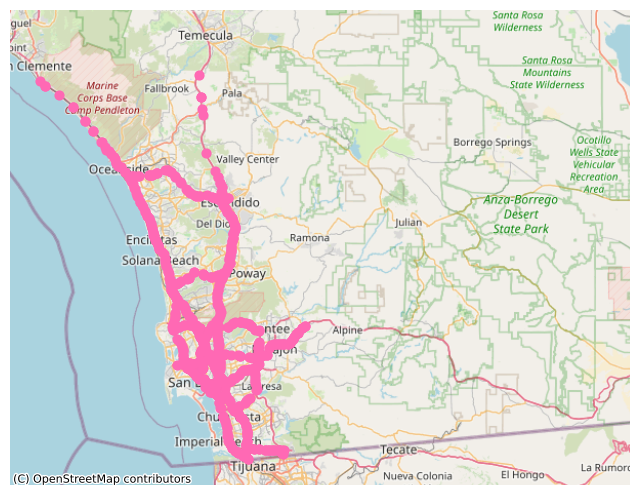

In [ ]:
ax = san_diego.to_crs(epsg=3857).plot(figsize=(8, 8), alpha=0)

gdf_web = gdf.to_crs(epsg=3857)
gdf_web.plot(ax=ax, color="hotpink", markersize=40)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()

In [35]:
import holidays

In [38]:
california_holidays = holidays.US(subdiv="CA", years=[2017, 2018, 2019])

In [41]:
california_holidays

{datetime.date(2017, 1, 1): "New Year's Day", datetime.date(2017, 1, 2): "New Year's Day (observed)", datetime.date(2017, 5, 29): 'Memorial Day', datetime.date(2017, 7, 4): 'Independence Day', datetime.date(2017, 9, 4): 'Labor Day', datetime.date(2017, 11, 23): 'Thanksgiving Day', datetime.date(2017, 12, 25): 'Christmas Day', datetime.date(2017, 1, 16): 'Martin Luther King Jr. Day', datetime.date(2017, 11, 11): 'Veterans Day', datetime.date(2017, 11, 10): 'Veterans Day (observed)', datetime.date(2017, 2, 20): "Presidents' Day", datetime.date(2017, 2, 15): 'Susan B. Anthony Day', datetime.date(2017, 3, 31): 'Cesar Chavez Day', datetime.date(2017, 11, 24): 'Day After Thanksgiving', datetime.date(2018, 1, 1): "New Year's Day", datetime.date(2018, 5, 28): 'Memorial Day', datetime.date(2018, 7, 4): 'Independence Day', datetime.date(2018, 9, 3): 'Labor Day', datetime.date(2018, 11, 22): 'Thanksgiving Day', datetime.date(2018, 12, 25): 'Christmas Day', datetime.date(2018, 1, 15): 'Martin Luth

In [42]:
meta_df

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
...,...,...,...,...,...,...,...,...,...,...
711,1123276,32.564373,-116.969279,11,San Diego,I905-W,3,Mainline,W,7642
712,1122394,32.564336,-116.961909,11,San Diego,I905-W,3,Mainline,W,7643
713,1123261,32.564112,-116.950744,11,San Diego,I905-W,3,Mainline,W,7644
714,1123256,32.560935,-116.944559,11,San Diego,I905-W,3,Mainline,W,7645


In [43]:
meta_df['Type'].value_counts()

Type
Mainline    716
Name: count, dtype: int64

In [44]:
meta_df['Fwy'].value_counts()

Fwy
I5-N       95
I5-S       86
I15-N      69
I15-S      58
I805-S     51
I805-N     49
I8-W       47
I8-E       39
SR78-W     24
SR78-E     20
SR94-W     20
SR125-N    19
SR52-W     18
SR94-E     16
SR163-S    15
SR56-E     13
SR52-E     13
I905-E     11
I905-W     11
SR125-S    11
SR56-W     11
SR163-N    10
SR54-W      3
SR11-W      3
SR54-E      3
SR11-E      1
Name: count, dtype: int64

In [45]:
meta_df['Lanes'].value_counts()

Lanes
4    315
5    139
3    134
2     73
6     48
7      5
8      2
Name: count, dtype: int64

TODO:

- [] Aggregate the sensor data by Fwy and Lanes and plot the average traffic volume for each group. This can help identify which freeways and lanes are more congested.
- [] Analyze the temporal patterns of traffic volume by plotting the average traffic volume for each hour of the day and each day of the week. This can help identify peak traffic hours and days.
- [] Analyze the spatial patterns of traffic volume by plotting the average traffic volume for each sensor location on a map of San Diego. This can help identify which areas of the city are more congested.
- [] Analyze the relationship between traffic volume and holidays by plotting the average traffic volume for each day of the year and highlighting the holidays. This can help identify if there are any significant changes in traffic volume during holidays.
- [] Identify any seasonal or trend patterns
- [] Cross analyse the traffic data for each year
- [] Correlation analysis between traffic volume and environmental factors such as weather conditions, air quality, and noise levels. This can help identify if there are any significant relationships between traffic volume and environmental factors.